In [41]:
import os
import pandas as pd

BASE_DIR = "."

## Filtrado

In [42]:
FILE_PATH = os.path.join(BASE_DIR, "bbdd_filtrada.csv")
CHUNK_SIZE = 1_000_000
STORE_NBR = 44

tamano_gb = os.path.getsize(FILE_PATH) / (1024**3)
print(f"Tamaño en disco: {tamano_gb:.2f} GB")


Tamaño en disco: 0.22 GB


In [43]:
partes = []

for i, chunk in enumerate(pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE, parse_dates=["date"])):
    partes.append(chunk[chunk["store_nbr"] == STORE_NBR])

    if (i + 1) % 5 == 0:
        print(f"Procesadas {(i + 1) * CHUNK_SIZE:,} filas leídas del archivo...")

bbdd_filtrada = pd.concat(partes, ignore_index=True)
print(f"\nFilas de la tienda 44: {len(bbdd_filtrada):,}")



Filas de la tienda 44: 1,599,702


## Revisión rápida

In [44]:
bbdd_filtrada.info()


<class 'pandas.DataFrame'>
RangeIndex: 1599702 entries, 0 to 1599701
Data columns (total 21 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   id            1599702 non-null  int64         
 1   date          1599702 non-null  datetime64[us]
 2   store_nbr     1599702 non-null  int64         
 3   item_nbr      1599702 non-null  int64         
 4   unit_sales    1599702 non-null  float64       
 5   onpromotion   1599702 non-null  bool          
 6   city          1599702 non-null  str           
 7   state         1599702 non-null  str           
 8   store_type    1599702 non-null  str           
 9   cluster       1599702 non-null  int64         
 10  transactions  1594596 non-null  float64       
 11  family        1599702 non-null  str           
 12  class         1599702 non-null  int64         
 13  perishable    1599702 non-null  int64         
 14  holiday_type  1599702 non-null  str           
 15  locale   

In [45]:
bbdd_filtrada.head(10)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,city,state,store_type,cluster,...,family,class,perishable,holiday_type,locale,locale_name,description,transferred,dcoilwtico,is_holiday
0,66538108,2016-01-02,44,103520,8.0,False,Quito,Pichincha,A,5,...,GROCERY I,1028,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
1,66539860,2016-01-02,44,1397779,2.0,False,Quito,Pichincha,A,5,...,GROCERY I,1030,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
2,66539861,2016-01-02,44,1397797,12.0,False,Quito,Pichincha,A,5,...,GROCERY I,1016,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
3,66539862,2016-01-02,44,1397802,8.0,False,Quito,Pichincha,A,5,...,GROCERY I,1016,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
4,66539863,2016-01-02,44,1398687,16.0,False,Quito,Pichincha,A,5,...,"LIQUOR,WINE,BEER",1387,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
5,66539864,2016-01-02,44,1398688,8.0,False,Quito,Pichincha,A,5,...,"LIQUOR,WINE,BEER",1387,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
6,66539865,2016-01-02,44,1399750,12.0,False,Quito,Pichincha,A,5,...,"LIQUOR,WINE,BEER",1318,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
7,66539866,2016-01-02,44,1400328,2.0,False,Quito,Pichincha,A,5,...,CLEANING,3016,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
8,66539859,2016-01-02,44,1397068,12.0,False,Quito,Pichincha,A,5,...,CLEANING,3032,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
9,66539867,2016-01-02,44,1400329,1.0,False,Quito,Pichincha,A,5,...,CLEANING,3016,0,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False


## Filtro de holidays (is_holiday) y relleno de oil (dcoilwtico)

In [46]:
# --- Filtro de holidays_events ---
# Rellenar valores nulos en las columnas de texto de holidays_events como 'no_holiday'
cols_holiday_texto = ["holiday_type", "locale", "locale_name", "description"]
for col in cols_holiday_texto:
    bbdd_filtrada[col] = bbdd_filtrada[col].fillna("no_holiday")

# 'transferred' es booleana; los NaN corresponden a fechas sin feriado -> False
bbdd_filtrada["transferred"] = bbdd_filtrada["transferred"].fillna(False).astype(bool)

# Columna is_holiday: True si es feriado nacional, o local de Quito/Pichincha
# (la tienda 44 está ubicada en Quito, Pichincha, así que estos son los feriados que la afectan)
bbdd_filtrada["is_holiday"] = (
    (bbdd_filtrada["locale"] == "National") |
    (bbdd_filtrada["locale_name"].str.lower().isin(["quito", "pichincha"]))
)

print(bbdd_filtrada["is_holiday"].value_counts())


is_holiday
False    1437271
True      162431
Name: count, dtype: int64


In [47]:
# --- Relleno de dcoilwtico (precio del petróleo) ---
# El petróleo no cotiza fines de semana/feriados, por eso hay NaN en esas fechas.
# Se ordena por fecha y se aplica forward-fill (arrastra el último valor conocido);
# se agrega un backward-fill solo por si la serie empieza con NaN (sin dato previo).
bbdd_filtrada = bbdd_filtrada.sort_values("date").reset_index(drop=True)

n_nulos_antes = bbdd_filtrada["dcoilwtico"].isna().sum()

bbdd_filtrada["dcoilwtico"] = bbdd_filtrada["dcoilwtico"].ffill()
bbdd_filtrada["dcoilwtico"] = bbdd_filtrada["dcoilwtico"].bfill()

n_nulos_despues = bbdd_filtrada["dcoilwtico"].isna().sum()
print(f"Nulos en dcoilwtico antes: {n_nulos_antes:,}")
print(f"Nulos en dcoilwtico después: {n_nulos_despues:,}")


Nulos en dcoilwtico antes: 0
Nulos en dcoilwtico después: 0


In [48]:
# Revisión rápida del resultado
bbdd_filtrada[["date", "holiday_type", "locale", "locale_name", "is_holiday", "dcoilwtico"]].head(10)


,date,holiday_type,locale,locale_name,is_holiday,dcoilwtico
0,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
1,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
2,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
3,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
4,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
5,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
6,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
7,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
8,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
9,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81


## Estadística descriptiva

### Nulos y duplicados

In [49]:
# Nulos por columna
nulos = bbdd_filtrada.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con valores nulos:")
print(nulos)


Columnas con valores nulos:
transactions    5106
dtype: int64


In [50]:
# Duplicados por 'id' (cada fila debería ser única)
n_duplicados_id = bbdd_filtrada["id"].duplicated().sum()
print(f"Filas con 'id' duplicado: {n_duplicados_id:,}")

# Duplicados considerando toda la fila
n_duplicados_totales = bbdd_filtrada.duplicated().sum()
print(f"Filas completamente duplicadas: {n_duplicados_totales:,}")


Filas con 'id' duplicado: 0
Filas completamente duplicadas: 0


### Estadísticas descriptivas — variables numéricas

In [51]:
# describe() sobre todas las columnas numéricas
cols_numericas = bbdd_filtrada.select_dtypes(include="number").columns.tolist()
print("Columnas numéricas:", cols_numericas)

bbdd_filtrada[cols_numericas].describe().T


Columnas numéricas: ['id', 'store_nbr', 'item_nbr', 'unit_sales', 'cluster', 'transactions', 'class', 'perishable', 'dcoilwtico']


,count,mean,std,min,25%,50%,75%,max
id,1599702.0,9.587842e+07,1.693451e+07,66538108.00,81301589.25,95726929.50,1.104718e+08,1.254739e+08
store_nbr,1599702.0,4.400000e+01,0.000000e+00,44.00,44.00,44.00,4.400000e+01,4.400000e+01
item_nbr,1599702.0,1.145530e+06,5.627907e+05,96995.00,696183.00,1171140.00,1.473478e+06,2.127114e+06
unit_sales,1599702.0,1.678787e+01,3.750396e+01,-363.00,3.00,8.00,1.700000e+01,3.556000e+03
cluster,1599702.0,5.000000e+00,0.000000e+00,5.00,5.00,5.00,5.000000e+00,5.000000e+00
transactions,1594596.0,4.384183e+03,7.002121e+02,3018.00,3842.00,4239.00,4.835000e+03,8.307000e+03
class,1599702.0,2.041248e+03,1.275535e+03,1002.00,1064.00,2004.00,2.712000e+03,7.780000e+03
perishable,1599702.0,2.703341e-01,4.441325e-01,0.00,0.00,0.00,1.000000e+00,1.000000e+00
dcoilwtico,1599702.0,4.581181e+01,6.287032e+00,26.19,43.62,47.24,4.985000e+01,5.448000e+01


### Estadísticas descriptivas — variables categóricas / booleanas

In [52]:
# describe() sobre columnas categóricas (incluye texto y booleanas)
cols_categoricas = bbdd_filtrada.select_dtypes(include=["object", "bool"]).columns.tolist()
print("Columnas categóricas:", cols_categoricas)

bbdd_filtrada[cols_categoricas].describe().T


C:\Users\56934\AppData\Local\Temp\ipykernel_6928\325766769.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = bbdd_filtrada.select_dtypes(include=["object", "bool"]).columns.tolist()


Columnas categóricas: ['onpromotion', 'city', 'state', 'store_type', 'family', 'holiday_type', 'locale', 'locale_name', 'description', 'transferred', 'is_holiday']


,count,unique,top,freq
onpromotion,1599702,2,False,1449330
city,1599702,1,Quito,1599702
state,1599702,1,Pichincha,1599702
store_type,1599702,1,A,1599702
family,1599702,32,GROCERY I,527210
holiday_type,1599702,6,no_holiday,1333417
locale,1599702,4,no_holiday,1333417
locale_name,1599702,23,no_holiday,1333417
description,1599702,76,no_holiday,1333417
transferred,1599702,2,False,1583915


In [53]:
# Detalle de frecuencias para las categóricas más relevantes
cols_categoricas_clave = [
    "family", "store_type", "city", "state",
    "holiday_type", "locale", "locale_name",
    "is_holiday", "onpromotion", "transferred"
]

for col in cols_categoricas_clave:
    if col in bbdd_filtrada.columns:
        print(f"\n--- {col} ---")
        print(bbdd_filtrada[col].value_counts(dropna=False))



--- family ---
family
GROCERY I                     527210
BEVERAGES                     243800
CLEANING                      180488
PRODUCE                       130852
DAIRY                         116425
BREAD/BAKERY                   57304
PERSONAL CARE                  57283
HOME CARE                      44627
DELI                           41010
MEATS                          30519
POULTRY                        25745
FROZEN FOODS                   20688
EGGS                           18187
LIQUOR,WINE,BEER               16009
HOME AND KITCHEN I             13815
HOME AND KITCHEN II             9413
PREPARED FOODS                  8391
CELEBRATION                     7973
LADIESWEAR                      6970
PLAYERS AND ELECTRONICS         6438
PET SUPPLIES                    5354
AUTOMOTIVE                      4696
GROCERY II                      4296
SEAFOOD                         4021
BEAUTY                          3804
LINGERIE                        3522
SCHOOL AND OFFI

### `unit_sales` según `is_holiday` y `onpromotion`

In [54]:
# Estadísticas de unit_sales agrupadas por is_holiday
resumen_holiday = bbdd_filtrada.groupby("is_holiday")["unit_sales"].agg(
    n="count", media="mean", mediana="median", desv_std="std", minimo="min", maximo="max"
)
print("unit_sales por is_holiday:")
resumen_holiday


unit_sales por is_holiday:


,n,media,mediana,desv_std,minimo,maximo
is_holiday,,,,,,
False,1437271,16.545622,8.0,36.416109,-363.0,3556.0
True,162431,18.931424,9.0,45.967264,-108.0,3009.0


In [55]:
# Estadísticas de unit_sales agrupadas por onpromotion
resumen_promo = bbdd_filtrada.groupby("onpromotion")["unit_sales"].agg(
    n="count", media="mean", mediana="median", desv_std="std", minimo="min", maximo="max"
)
print("unit_sales por onpromotion:")
resumen_promo


unit_sales por onpromotion:


,n,media,mediana,desv_std,minimo,maximo
onpromotion,,,,,,
False,1449330,15.539549,7.4625,34.122914,-363.0,3009.0
True,150372,28.819583,14.0000,59.840877,-2.0,3556.0


In [56]:
# Cruce is_holiday x onpromotion: media de unit_sales en cada combinación
resumen_cruzado = bbdd_filtrada.groupby(["is_holiday", "onpromotion"])["unit_sales"].agg(
    n="count", media="mean", mediana="median"
)
print("unit_sales por is_holiday x onpromotion:")
resumen_cruzado


unit_sales por is_holiday x onpromotion:


n      media  mediana
is_holiday onpromotion                             
False      False        1303176  15.284782      7.0
           True          134095  28.798848     14.0
True       False         146154  17.811167      8.0
           True           16277  28.990408     14.0

Estadistica descriptiva por productos


In [27]:
# 1. Resumen descriptivo por SKU (item_nbr)
resumen_sku = bbdd_filtrada.groupby("item_nbr").agg(
    observaciones=("unit_sales", "count"),
    media_ventas=("unit_sales", "mean"),
    fecha_inicio=("date", "min"),
    fecha_fin=("date", "max")
).reset_index()

# 2. Filtrar y mostrar los 10 SKU MÁS VENDIDOS (por promedio de ventas)
top_10_mas_vendidos = resumen_sku.sort_values(by="media_ventas", ascending=False).head(10)
top_10_mas_vendidos

,item_nbr,observaciones,media_ventas,fecha_inicio,fecha_fin
2550,1503844,590,716.189425,2016-01-02,2017-08-15
2486,1473474,590,488.064847,2016-01-02,2017-08-15
1309,1047679,590,464.013559,2016-01-02,2017-08-15
3478,2042941,225,433.515556,2017-01-03,2017-08-15
2134,1430040,585,430.075214,2016-01-02,2017-08-15
3239,2006812,339,371.064897,2016-08-23,2017-08-15
3479,2042947,225,346.822222,2017-01-02,2017-08-15
1025,856688,37,285.351351,2016-11-21,2016-12-28
2638,1642399,585,242.921450,2016-01-02,2017-08-15
1024,856687,37,240.918919,2016-11-21,2017-01-02


In [29]:
# Detectar el nombre correcto de la columna de categoría (family o category)
col_categoria = "family" if "family" in bbdd_filtrada.columns else "category" if "category" in bbdd_filtrada.columns else "Category"

# Resumen descriptivo por SKU agregando la categoría
resumen_sku_categoria = bbdd_filtrada.groupby(["item_nbr", col_categoria]).agg(
    observaciones=("unit_sales", "count"),
    media_ventas=("unit_sales", "mean"),
    fecha_inicio=("date", "min"),
    fecha_fin=("date", "max")
).reset_index()

# Los 10 SKU MÁS VENDIDOS con su tipo de producto
top_10_con_tipo = resumen_sku_categoria.sort_values(by="media_ventas", ascending=False).head(10)
top_10_con_tipo

,item_nbr,family,observaciones,media_ventas,fecha_inicio,fecha_fin
2550,1503844,PRODUCE,590,716.189425,2016-01-02,2017-08-15
2486,1473474,PRODUCE,590,488.064847,2016-01-02,2017-08-15
1309,1047679,BEVERAGES,590,464.013559,2016-01-02,2017-08-15
3478,2042941,BEVERAGES,225,433.515556,2017-01-03,2017-08-15
2134,1430040,BEVERAGES,585,430.075214,2016-01-02,2017-08-15
3239,2006812,BEVERAGES,339,371.064897,2016-08-23,2017-08-15
3479,2042947,BEVERAGES,225,346.822222,2017-01-02,2017-08-15
1025,856688,GROCERY I,37,285.351351,2016-11-21,2016-12-28
2638,1642399,PRODUCE,585,242.921450,2016-01-02,2017-08-15
1024,856687,GROCERY I,37,240.918919,2016-11-21,2017-01-02


In [58]:
# 1. Lista exacta de los 10 SKU requeridos
skus_requeridos = [
    1503844,
    1473474,
    1047679,
    2042941,
    1430040,
    2006812,
    2042947,
    856688,
    1642399,
    856687,
]

# 2. Filtrar para el período 2016-2017 y los SKU específicos
df_skus = bbdd_filtrada[
    (bbdd_filtrada["item_nbr"].isin(skus_requeridos))
    & (pd.to_datetime(bbdd_filtrada["date"]).dt.year.isin([2016, 2017]))
].copy()

df_skus["date"] = pd.to_datetime(df_skus["date"])

# 3. Agregación diaria por date + item_nbr
ts_diaria = (
    df_skus.groupby(["date", "item_nbr"])["unit_sales"].sum().reset_index()
)

# 4. Rellenar días faltantes con 0 dentro del rango 2016-01-01 a 2017-08-15
rango_fechas = pd.date_range(start="2016-01-01", end="2017-08-15")
df_completo = []

for sku in skus_requeridos:
    df_sku = ts_diaria[ts_diaria["item_nbr"] == sku].set_index("date")
    df_sku = df_sku.reindex(rango_fechas, fill_value=0).reset_index()
    df_sku.rename(columns={"index": "date"}, inplace=True)
    df_sku["item_nbr"] = sku
    df_completo.append(df_sku)

df_analisis = pd.concat(df_completo, ignore_index=True)

# 5. Obtener mapeo de categorías (family)
if "family" in bbdd_filtrada.columns:
    sku_family = (
        bbdd_filtrada.groupby("item_nbr")["family"].first().to_dict()
    )
else:
    sku_family = {sku: "General" for sku in skus_requeridos}

# 6. Calcular Estadísticas Descriptivas respetando la lista exacta
stats_list = []

for sku in skus_requeridos:
    data = df_analisis[df_analisis["item_nbr"] == sku]["unit_sales"]

    mean = data.mean()
    std = data.std()
    cv = (std / mean) * 100 if mean > 0 else 0

    stats_list.append(
        {
            "SKU": sku,
            "Categoría": sku_family.get(sku, "N/A"),
            "Ventas Totales": round(data.sum(), 0),
            "Promedio Diario": round(mean, 1),
            "Mediana": round(data.median(), 1),
            "Desv. Estándar": round(std, 1),
            "Mínimo": data.min(),
            "Máximo (Pico)": data.max(),
            "Coef. Variación (%)": round(cv, 1),
            "Sesgo (Skewness)": round(data.skew(), 2),
            "Días con Venta 0": (data == 0).sum(),
        }
    )

df_estadisticas_especificas = pd.DataFrame(stats_list)

# Mostrar la tabla en el cuaderno
display(df_estadisticas_especificas)

,SKU,Categoría,Ventas Totales,Promedio Diario,Mediana,Desv. Estándar,Mínimo,Máximo (Pico),Coef. Variación (%),Sesgo (Skewness),Días con Venta 0
0,1503844,PRODUCE,422552.0,712.6,666.3,247.4,0.0,1362.554,34.7,0.32,3
1,1473474,PRODUCE,287958.0,485.6,460.4,140.7,0.0,982.696,29.0,0.15,3
2,1047679,BEVERAGES,273768.0,461.7,443.0,201.8,0.0,1561.000,43.7,0.94,3
3,2042941,BEVERAGES,97541.0,164.5,0.0,259.5,0.0,1960.000,157.8,2.12,368
4,1430040,BEVERAGES,251594.0,424.3,405.0,287.0,0.0,2846.000,67.7,1.42,8
5,2006812,BEVERAGES,125791.0,212.1,131.0,289.9,0.0,2970.000,136.7,2.95,254
6,2042947,BEVERAGES,78035.0,131.6,0.0,228.9,0.0,1906.000,173.9,3.05,368
7,856688,GROCERY I,10558.0,17.8,0.0,121.0,0.0,1641.000,679.7,9.24,556
8,1642399,PRODUCE,142109.0,239.6,221.4,100.7,0.0,685.167,42.0,0.70,8
9,856687,GROCERY I,8914.0,15.0,0.0,108.8,0.0,1571.000,723.5,10.30,556


In [ ]:
# Produce: frutas/ verduras/alimentos frescos, de alta rotación díaria
# Beverages: aguas/ jugos / liquidos
# Grocery I: abarrotes 1ra necesidad / despensa / no perecibles 

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

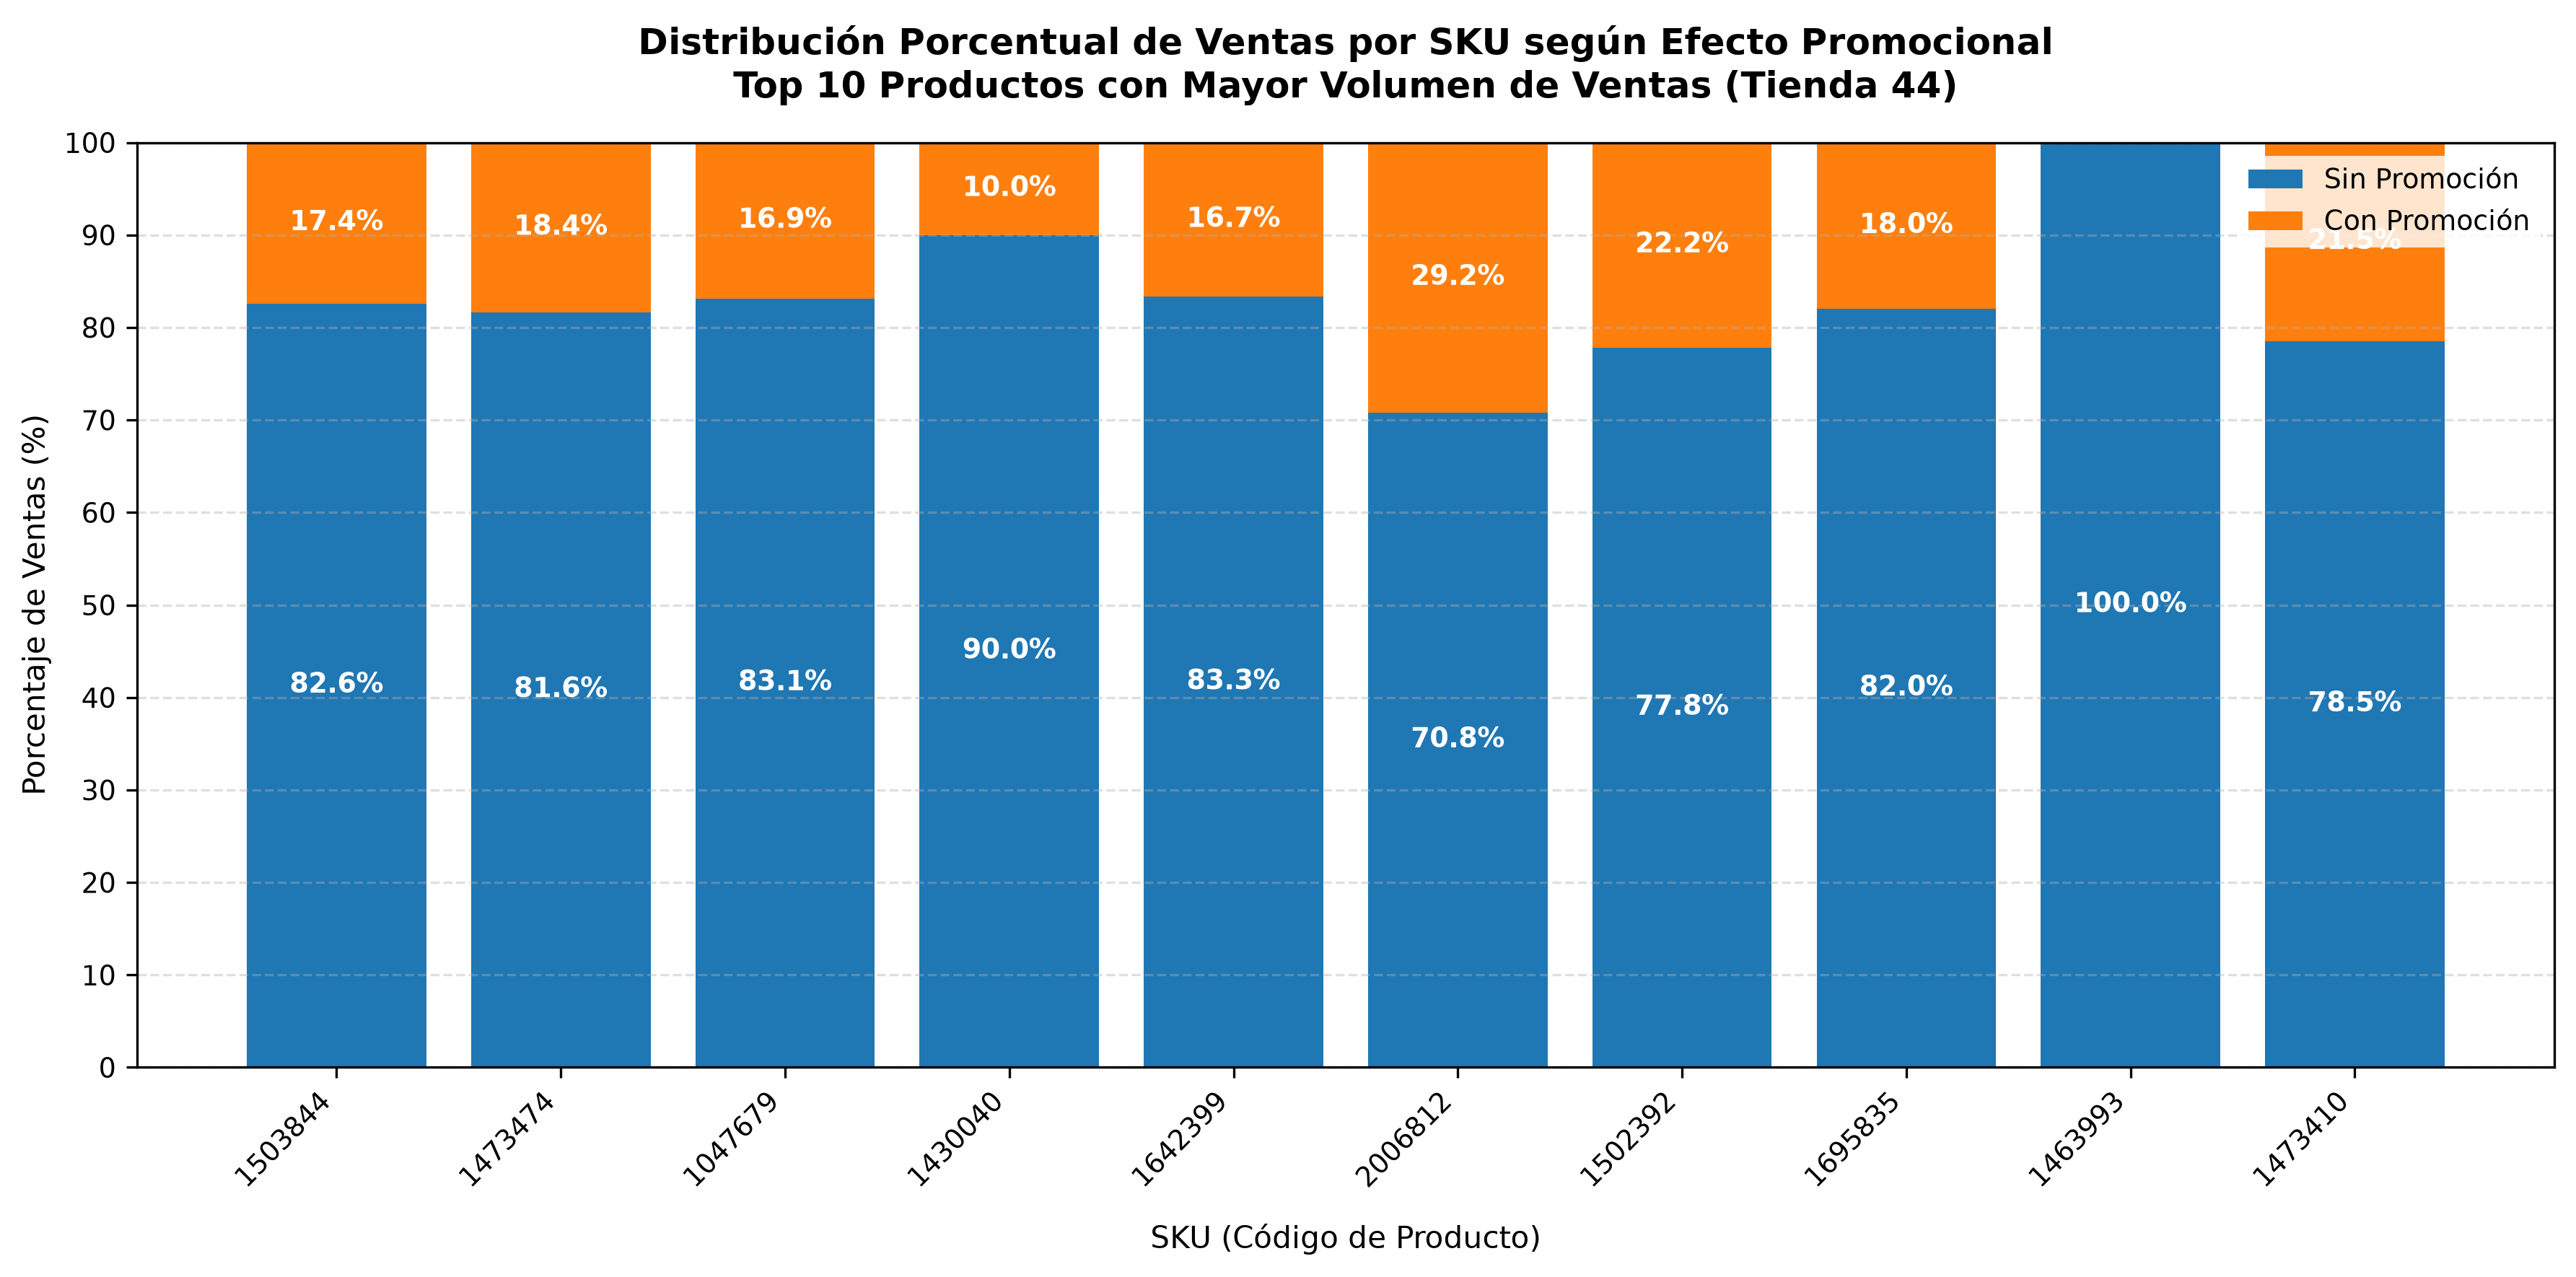

In [31]:
# 1. Obtener los 10 SKU principales por ventas totales
top_10_skus = (
    bbdd_filtrada.groupby("item_nbr")["unit_sales"]
    .sum()
    .nlargest(10)
    .index.tolist()
)

# 2. Filtrar la base de datos para estos 10 SKU
df_top10 = bbdd_filtrada[bbdd_filtrada["item_nbr"].isin(top_10_skus)].copy()

# 3. Calcular ventas con promoción (True) y sin promoción (False) por SKU
ventas_promo = (
    df_top10.groupby(["item_nbr", "onpromotion"])["unit_sales"]
    .sum()
    .unstack(fill_value=0)
)

# Asegurar que existan ambas columnas (False y True)
if True not in ventas_promo.columns:
    ventas_promo[True] = 0
if False not in ventas_promo.columns:
    ventas_promo[False] = 0

# Ventas totales por SKU
ventas_promo["total_sales"] = ventas_promo[True] + ventas_promo[False]

# 4. Ordenar de mayor a menor ventas totales (Principio de Pareto)
ventas_promo = ventas_promo.sort_values(by="total_sales", ascending=False)

# 5. Calcular los porcentajes requeridos
# % de ventas en promo / sin promo dentro del mismo SKU
ventas_promo["pct_no_promo"] = (
    ventas_promo[False] / ventas_promo["total_sales"]
) * 100
ventas_promo["pct_promo"] = (
    ventas_promo[True] / ventas_promo["total_sales"]
) * 100

# Convertir SKU a texto para el eje X
skus = [str(sku) for sku in ventas_promo.index]
pct_no_promo = ventas_promo["pct_no_promo"].values
pct_promo = ventas_promo["pct_promo"].values

# 6. Configuración del gráfico para Tesis
plt.figure(figsize=(12, 6), dpi=300)

# Graficar barras apiladas al 100%
bar1 = plt.bar(
    skus, pct_no_promo, label="Sin Promoción", color="#1f77b4", edgecolor="none"
)
bar2 = plt.bar(
    skus,
    pct_promo,
    bottom=pct_no_promo,
    label="Con Promoción",
    color="#ff7f0e",
    edgecolor="none",
)

# 7. Agregar etiquetas de porcentaje dentro de las barras
for i in range(len(skus)):
    val_no_promo = pct_no_promo[i]
    val_promo = pct_promo[i]

    # Etiqueta para 'Sin Promoción' (si es visible)
    if val_no_promo > 5:
        plt.text(
            i,
            val_no_promo / 2,
            f"{val_no_promo:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

    # Etiqueta para 'Con Promoción' (si es visible)
    if val_promo > 5:
        plt.text(
            i,
            val_no_promo + (val_promo / 2),
            f"{val_promo:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

# 8. Ajustes estéticos y formato del gráfico
plt.title(
    "Distribución Porcentual de Ventas por SKU según Efecto Promocional\nTop 10 Productos con Mayor Volumen de Ventas (Tienda 44)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("SKU (Código de Producto)", fontsize=10, labelpad=10)
plt.ylabel("Porcentaje de Ventas (%)", fontsize=10)
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(np.arange(0, 101, 10), fontsize=9)

# Cuadrícula horizontal sutil
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Leyenda
plt.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=9,
)

plt.tight_layout()
plt.show()

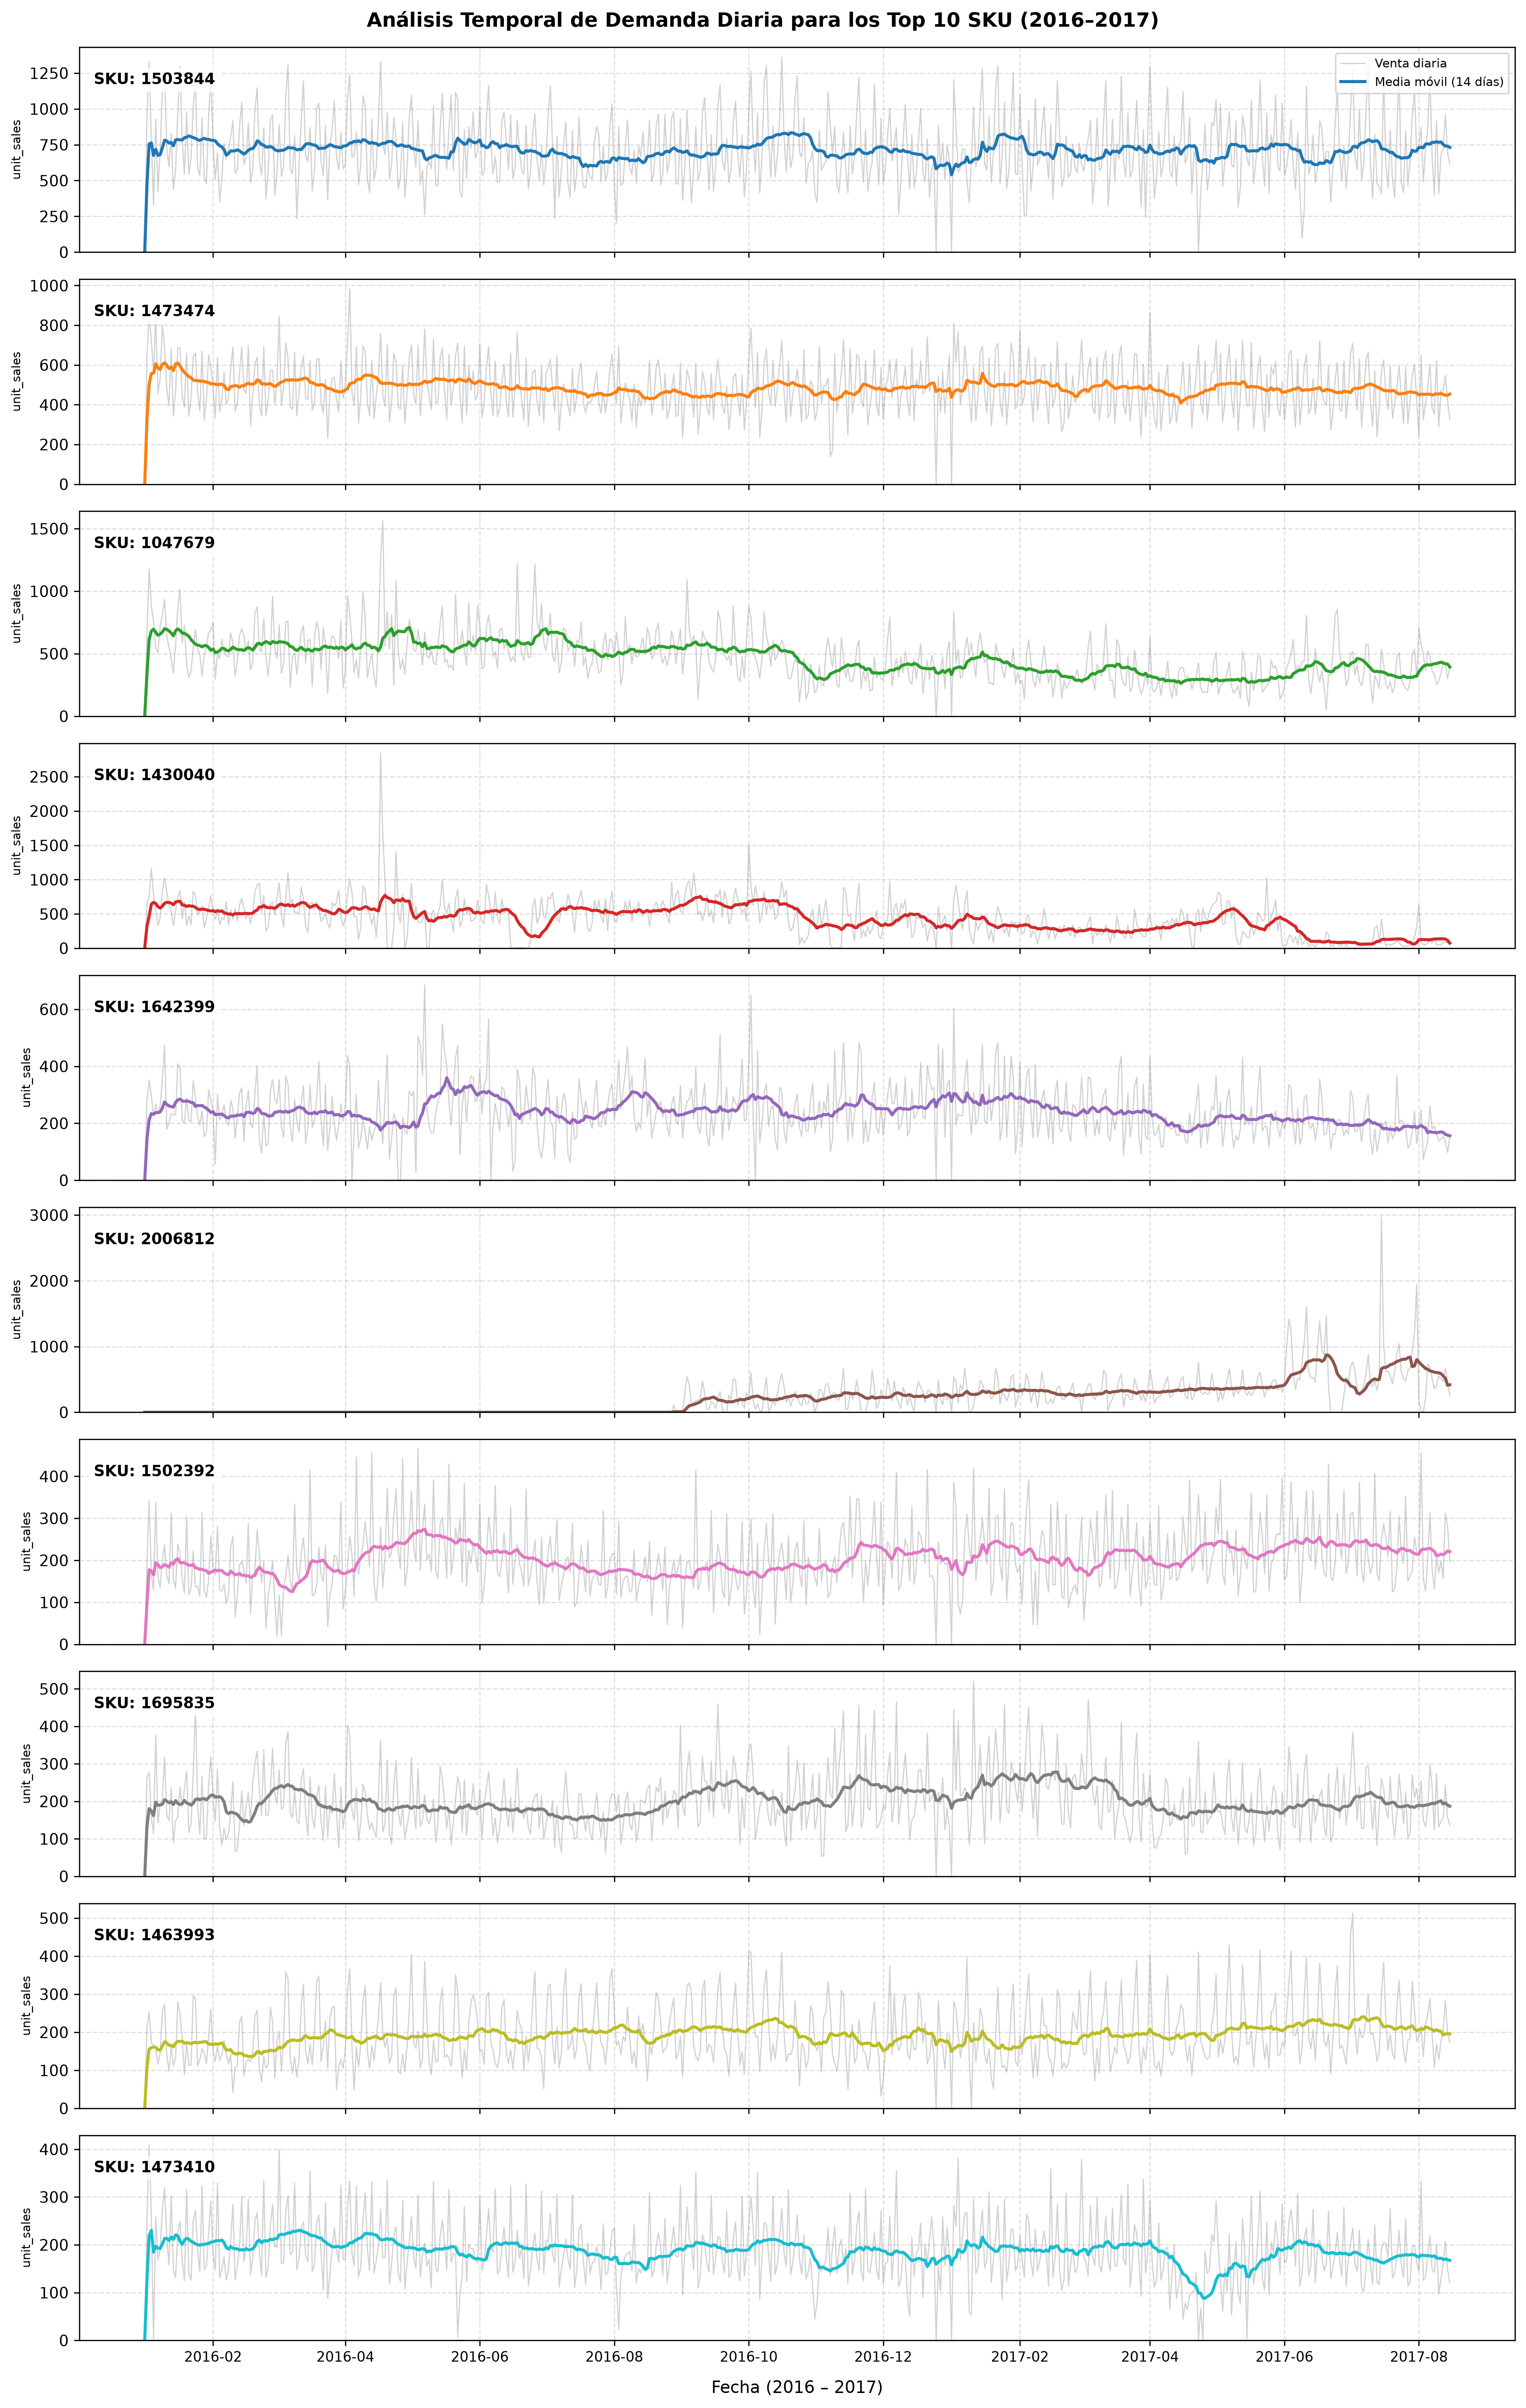

In [37]:

# 1. Asegurar formato de fecha en la base de datos
bbdd_filtrada["date"] = pd.to_datetime(bbdd_filtrada["date"])

# 2. Reutilizar exactamente los mismos Top 10 SKU por ventas totales
top_10_skus = (
    bbdd_filtrada.groupby("item_nbr")["unit_sales"]
    .sum()
    .nlargest(10)
    .index.tolist()
)

# 3. Filtrar para el período 2016–2017 y los 10 SKU seleccionados
df_ts = bbdd_filtrada[
    (bbdd_filtrada["item_nbr"].isin(top_10_skus))
    & (bbdd_filtrada["date"].dt.year.isin([2016, 2017]))
].copy()

# 4. Agregación diaria por date + item_nbr
ts_diaria = (
    df_ts.groupby(["date", "item_nbr"])["unit_sales"].sum().reset_index()
)

# 5. Crear estructura de subgráficos (10 filas x 1 columna)
fig, axes = plt.subplots(
    nrows=10, ncols=1, figsize=(14, 22), sharex=True, dpi=300
)

# Paleta de colores para destacar cada serie
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, sku in enumerate(top_10_skus):
    ax = axes[i]

    # Subconjunto por SKU y orden cronológico
    df_sku = ts_diaria[ts_diaria["item_nbr"] == sku].sort_values("date")

    # Reorganizar el índice por fecha completa para rellenar días faltantes con 0 si los hubiera
    rango_fechas = pd.date_range(start="2016-01-01", end="2017-08-15")
    df_sku = (
        df_sku.set_index("date")
        .reindex(rango_fechas, fill_value=0)
        .reset_index()
    )
    df_sku.rename(columns={"index": "date"}, inplace=True)

    # Calcular media móvil de 14 días (suavizado de tendencia)
    df_sku["rolling_14"] = df_sku["unit_sales"].rolling(window=14, min_periods=1).mean()

    # Etiqueta del subgráfico (Muestra únicamente el SKU)
    ax.text(
        0.01,
        0.82,
        f"SKU: {sku}",
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none"),
    )

    # Graficar Demanda Diaria (en gris/transparente)
    ax.plot(
        df_sku["date"],
        df_sku["unit_sales"],
        color="gray",
        alpha=0.35,
        linewidth=0.8,
        label="Venta diaria",
    )

    # Graficar Media Móvil 14 días (color resaltado)
    ax.plot(
        df_sku["date"],
        df_sku["rolling_14"],
        color=colors[i],
        linewidth=2.0,
        label="Media móvil (14 días)",
    )

    # Ajustes estéticos de cada subgráfico
    ax.set_ylabel("unit_sales", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylim(bottom=0)

    # Leyenda en el primer gráfico
    if i == 0:
        ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white")

# Configuración del eje X global
axes[-1].set_xlabel("Fecha (2016 – 2017)", fontsize=11, labelpad=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=0, fontsize=9)

# Título Principal (Limpio, sin la línea de Tienda 44)
fig.suptitle(
    "Análisis Temporal de Demanda Diaria para los Top 10 SKU (2016–2017)",
    fontsize=13,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout()
plt.subplots_adjust(top=0.98)
plt.show()

## Guardar el resultado

In [59]:
OUTPUT_PATH = os.path.join(BASE_DIR, "bbdd_filtrada.csv")
bbdd_filtrada.to_csv(OUTPUT_PATH, index=False)
print("Guardado en:", OUTPUT_PATH)


Guardado en: .\bbdd_filtrada.csv
